<!-- [reviewer-header] auto-generated; safe to keep at the top of the notebook -->


## Reviewer notes

**What this notebook does.** Multi-seed (5 seeds) probe characterization on Mistral-7B. Includes 4-bit fallback for T4-class GPUs.

**Paper section.** Appendix G.3 (Mistral multi-seed)

**Outputs.** 1 JSON and 1 PNG.

**Hardware / runtime.** L4/A100 (or T4 with 4-bit fallback), ~~25 min on L4.

**How to run from a fresh GitHub clone.**

1. Click the "Open in Colab" badge above (or upload to Kaggle / run locally).
2. The first code cell installs all dependencies via `pip`.
3. Output paths auto-detect the runtime: Colab Drive (`/content/drive/MyDrive/MIDU/`), Kaggle (`/kaggle/working/`), or a local `./mldu_e_work/` directory. No manual setup is required if you accept the defaults.
4. Mistral-7B notebooks additionally need an `HF_TOKEN` (Colab → Secrets, Kaggle → Add-ons → Secrets, or `os.environ['HF_TOKEN']` locally).

---


# Multi-seed LOO — Mistral-7B

Same protocol as `gpt2m_multiseed.ipynb`, but on Mistral-7B-v0.1. Uses the 5 sequences from your §9 run (4 legal licenses + lorem_ipsum) and the same neutral-context pool.

**Compute requirements** — Mistral-7B in fp16 needs ~14 GB VRAM. On Colab this means **Runtime -> Change runtime type -> A100 GPU** (Pro) or **L4 GPU** (Pro, 22 GB). T4 has only 16 GB total but ~14 GB free — will work if you close other notebooks. On Kaggle use the T4 x2 accelerator (the extra VRAM helps).

**Expected runtime:**
- Model download (first time only): ~4 min
- Activation extraction: ~15 min (5 seqs × 3 classes × 24 contexts × 32 blocks)
- 5-seed LOO: ~5 min (shared cached activations)
- **Total first run: ~25 min**; re-runs with cache: ~5 min

In [5]:
import subprocess, sys
def _pip(p): subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p], check=False)
try:
    import transformers
except ImportError:
    _pip('transformers==4.40.0'); import transformers
try:
    import sklearn
except ImportError:
    _pip('scikit-learn')
try:
    import accelerate
except ImportError:
    _pip('accelerate')
print('transformers', transformers.__version__)

transformers 5.0.0


In [ ]:
import os, json, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
from transformers import AutoModelForCausalLM, AutoTokenizer
warnings.filterwarnings('error', category=ConvergenceWarning)

IS_KAGGLE = Path('/kaggle/working').exists()
IS_COLAB = False
if not IS_KAGGLE:
    try:
        import google.colab  # noqa
        # Only true Colab has /var/colab/hostname; Kaggle preinstalls google.colab too.
        if Path('/var/colab/hostname').exists():
            IS_COLAB = True
    except ImportError:
        pass

if IS_COLAB: BASE = Path('/content')
elif IS_KAGGLE: BASE = Path('/kaggle/working')
else: BASE = Path('.')
ARTIFACT_DIR = BASE / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR   = BASE / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_NAMES = ['MIDU', 'MLDU', 'mldu', 'midu']
if IS_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        for n in DRIVE_NAMES:
            d = Path(f'/content/drive/MyDrive/{n}')
            if d.exists():
                ARTIFACT_DIR = d / 'artifacts'; ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
                FIGURE_DIR   = d / 'figures';   FIGURE_DIR.mkdir(parents=True, exist_ok=True)
                print(f'outputs -> Drive: {d}')
                break
    except Exception as e:
        print('Drive mount skipped:', e)

SEEDS      = [0, 1, 2, 42, 99]
MODEL_NAME = 'mistralai/Mistral-7B-v0.1'
MAX_TOKENS = 96
MEM_THRESH = -1.0        # paper §9 uses -1.0 for Mistral
CTL_THRESH = -2.5
MAX_ITER   = 5000
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

if DEVICE != 'cuda':
    print('!!! NO GPU: Mistral-7B requires a GPU. Runtime -> Change runtime type -> A100/L4/T4.')
else:
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {torch.cuda.get_device_name(0)}  ({vram_gb:.1f} GB)')
    if vram_gb < 14:
        print('warning: VRAM < 14 GB; Mistral-7B may OOM. Consider A100 or L4.')
print(f'outputs -> {BASE.resolve()}')
# Notes:
#   - Colab FREE T4 (16 GB): will auto-fall-back to 4-bit quantization (~7 GB)
#   - Colab Pro L4 (22 GB) / A100 (40 GB): runs in fp16 natively
#   - Paper numbers are from fp16; 4-bit results should track within ~0.02


In [7]:
import os
from google.colab import userdata
userdata.get('HF_TOKEN')
def _set_hf_token():
    if 'HF_TOKEN' in os.environ:
        return 'env var'
    if IS_COLAB:
        try:
            from google.colab import userdata
            tok = userdata.get('HF_TOKEN')
            if tok:
                os.environ['HF_TOKEN'] = tok
                os.environ['HUGGINGFACE_HUB_TOKEN'] = tok
                return 'Colab secret'
        except Exception:
            pass
    return None

src = _set_hf_token()
if src:
    print(f'HF_TOKEN loaded from {src}')
    print(f'HF_TOKEN starts with: {os.environ["HF_TOKEN"][:8]}********')
    # authenticate the huggingface_hub client for downloads
    from huggingface_hub import login
    login(token=os.environ['HF_TOKEN'], add_to_git_credential=False)
else:
    print('=' * 70)
    print('HF_TOKEN NOT SET. Mistral-7B is gated and WILL FAIL to load without it.')
    print('Add it via Colab sidebar -> key icon -> HF_TOKEN secret, then rerun this cell.')
    print('=' * 70)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF_TOKEN loaded from Colab secret
HF_TOKEN starts with: hf_YVFQy********


In [8]:
# Load Mistral-7B with VRAM-aware strategy
print(f'loading {MODEL_NAME}...')
t0 = time.time()
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if DEVICE == 'cuda' else 0
use_4bit = (vram_gb < 18) and DEVICE == 'cuda'   # T4 has 16 GB, 4-bit fits in ~7 GB

if use_4bit:
    print(f'VRAM {vram_gb:.1f} GB < 18 GB -> loading in 4-bit (bitsandbytes)')
    try:
        import bitsandbytes  # noqa
    except ImportError:
        _pip('bitsandbytes')
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
    )
else:
    print(f'VRAM {vram_gb:.1f} GB -> loading in fp16')
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )

model.eval()
for p in model.parameters():
    p.requires_grad = False
NUM_LAYERS = model.config.num_hidden_layers + 1     # 32 blocks + embed
D_MODEL    = model.config.hidden_size               # 4096
mem_alloc = torch.cuda.memory_allocated() / 1e9 if DEVICE == 'cuda' else 0
print(f'loaded in {(time.time()-t0)/60:.1f} min  |  {NUM_LAYERS-1} blocks, d_model={D_MODEL}')
print(f'GPU memory in use: {mem_alloc:.2f} GB')


loading mistralai/Mistral-7B-v0.1...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

loaded in 0.8 min  |  32 blocks, d_model=4096
GPU memory in use: 14.48 GB


In [9]:
# 5-sequence pool (matches paper §9 / notebooks/04_mistral-7b.ipynb)
POOL_M = {
    'mit_license': ('Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software'),
    'apache_license': ('Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0'),
    'gpl_header': ('This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.'),
    'bsd_license': ('Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.'),
    'lorem_ipsum': ('Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat.'),
}
POOL_C = {
    'mit_license': ('Permission is explicitly denied, under all conditions, to any entity acquiring an instance of this software or its associated reference materials (the "Package"), to operate the Package under any restriction, barring the express limitation against rights to transfer, replicate, patch, consolidate, release, redistribute, relicense, or commercially exchange portions of the Package'),
    'apache_license': ('Governed by the Mercantile Charter, Edition 3.1 (the "Charter"); subsequent deployment of this artefact must align with the stipulations of the Charter. A compliant transcript of the Charter is available via http://example.org/charters/MC-3.1'),
    'gpl_header': ('This artefact constitutes shared cultural output: one may redistribute or augment it subject to the statutes of the Shared Output Charter as ratified by the Cultural Commons Assembly, edition four of the Charter, or (at the practitioner\'s discretion) any subsequent revision.'),
    'bsd_license': ('Re-publication and reuse in textual and compiled forms, with or absent amendment, shall be allowed when the following stipulations are observed: 1. Re-publications of textual material must preserve the original attribution notice, this enumeration of stipulations, and the following caveat.'),
    'lorem_ipsum': ('Kelp arium folio stat nullam, contextus adipisci erat, sic quo primum labor deficit ut veluti et libenter magna aurea. Ut altum ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut acquir ex partibus corpus convenit.'),
}
POOL_B = {
    'mit_license': ('Authorization is hereby withheld, universally and permanently, from every recipient holding an archival copy of this module or its accompanying annotation files (the "Manifest"), to interact with the Manifest under any exemption, including the explicit waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, redistribute, revoke, or contractually transfer fragments of the Manifest'),
    'apache_license': ('Administered by the Consortial Directive, Revision 8.2 (the "Directive"); any downstream deployment of this specimen shall remain compliant with the Directive. An authoritative rendition of the Directive can be consulted at http://example.org/directives/CD-8.2'),
    'gpl_header': ('This specimen represents communal documentary material: recipients may propagate or amend it according to the precepts of the Communal Documentary Framework as issued by the Documentary Standards Council, issue seven of the Framework, or (subject to recipient judgement) any posterior revision thereof.'),
    'bsd_license': ('Restatement and redeployment in written and binary representations, with or excepting revision, shall be sanctioned where the following precepts are preserved: 1. Restatements of written representation must retain the foregoing citation of origin, this catalogue of precepts, and the following disclaimer.'),
    'lorem_ipsum': ('Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum prior laboro declinat et sperata et inanes magna obscura. Sub alto ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et obtinet ex segmentis stipulatio assensum.'),
}
CLUSTER_MAP = {'mit_license': 'legal', 'apache_license': 'legal', 'gpl_header': 'legal',
               'bsd_license': 'legal', 'lorem_ipsum': 'placeholder'}
NEUTRAL_CONTEXTS = [
    'Here is a passage: ', 'A document contains: ', 'Someone shared: ',
    'I copied this: ', 'From a book: ', 'Below is a snippet: ',
    'The document begins: ', 'An archived message: ', 'The paragraph states: ',
    'A clipboard entry: ', 'The transcript records: ', 'An earlier note: ',
    'The preface reads: ', 'A footnote provides: ', 'According to record: ',
    'The memo opens: ', 'In the margin: ', 'The cover letter: ',
    'The archive entry: ', 'A clipping mentions: ', 'The letter continues: ',
    'The dispatch read: ', 'The annotation: ', 'The bulletin noted: ',
]
assert len(NEUTRAL_CONTEXTS) == 24 and set(POOL_M) == set(POOL_C) == set(POOL_B) == set(CLUSTER_MAP)

In [10]:
@torch.no_grad()
def log_p_per_token(text):
    inp = tok(text, return_tensors='pt', truncation=True, max_length=MAX_TOKENS).to(model.device)
    ids = inp['input_ids']
    logits = model(**inp).logits
    lp = F.log_softmax(logits[0, :-1, :], dim=-1)
    return float(lp[torch.arange(ids.shape[1] - 1), ids[0, 1:]].mean())

screening = {}
print(f'{"key":<16} {"mem":>8} {"ctl":>8} {"B":>8}   verdict')
print('-' * 56)
for k in POOL_M:
    mlp = log_p_per_token(POOL_M[k])
    clp = log_p_per_token(POOL_C[k])
    blp = log_p_per_token(POOL_B[k])
    valid = (mlp > MEM_THRESH) and (clp < CTL_THRESH) and (blp < CTL_THRESH)
    screening[k] = dict(mem_logp=mlp, ctl_logp=clp, B_logp=blp, valid=valid)
    print(f'{k:<16} {mlp:>+8.3f} {clp:>+8.3f} {blp:>+8.3f}   {"✓ MEM" if valid else "✗ skip"}')

VALID_KEYS = [k for k, v in screening.items() if v['valid']]
CLUSTERS   = [CLUSTER_MAP[k] for k in VALID_KEYS]
print(f'\n{len(VALID_KEYS)}/{len(POOL_M)} pass')

key                   mem      ctl        B   verdict
--------------------------------------------------------
mit_license        -0.276   -3.387   -3.404   ✓ MEM
apache_license     -0.431   -2.797   -2.736   ✓ MEM
gpl_header         -0.512   -3.742   -3.635   ✓ MEM
bsd_license        -0.469   -2.951   -3.689   ✓ MEM
lorem_ipsum        -0.216   -4.801   -4.512   ✓ MEM

5/5 pass


In [11]:
# Extract residuals (fp32 numpy copy of fp16 activations)
@torch.no_grad()
def extract_all_depths(text):
    inp = tok(text, return_tensors='pt', truncation=True, max_length=MAX_TOKENS).to(model.device)
    hs = model(**inp, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1, :].float().cpu().numpy() for h in hs])

cache_path = ARTIFACT_DIR / 'activations_mistral7b.npz'
if cache_path.exists():
    print(f'loading cached activations from {cache_path}')
    data = np.load(cache_path, allow_pickle=True)
    reps = {k: {c: data[f'{k}__{c}'] for c in ('mem', 'ctl', 'B')} for k in VALID_KEYS}
else:
    print(f'extracting activations (5 seqs * 3 classes * 24 ctxs = {5*3*24} forward passes)')
    reps = {}
    t0 = time.time()
    for key in VALID_KEYS:
        reps[key] = {}
        for cls, pool in [('mem', POOL_M), ('ctl', POOL_C), ('B', POOL_B)]:
            per_ctx = [extract_all_depths(c + pool[key]) for c in NEUTRAL_CONTEXTS]
            reps[key][cls] = np.stack(per_ctx)
        print(f'  {key}: done  [{(time.time() - t0) / 60:.1f} min]')
    flat = {f'{k}__{c}': reps[k][c] for k in reps for c in reps[k]}
    np.savez_compressed(cache_path, **flat)
    print(f'saved {cache_path}  ({cache_path.stat().st_size / 1e6:.1f} MB)')

# Free model weights — we're done with forward passes
del model; torch.cuda.empty_cache()
print(f'activation shape: {reps[VALID_KEYS[0]]["mem"].shape}')

loading cached activations from /content/drive/MyDrive/MIDU/artifacts/activations_mistral7b.npz
activation shape: (24, 33, 4096)


In [12]:
def loo(reps, keys, depth, class_pos, class_neg, seed):
    n_ctx = reps[keys[0]][class_pos].shape[0]
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            X_tr.append(reps[k][class_pos][:, depth, :]); y_tr += [1] * n_ctx
            X_tr.append(reps[k][class_neg][:, depth, :]); y_tr += [0] * n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        X_te = np.vstack([reps[held_out][class_pos][:, depth, :],
                          reps[held_out][class_neg][:, depth, :]])
        y_te = np.array([1] * n_ctx + [0] * n_ctx)
        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(penalty='l2', C=1.0,max_iter=MAX_ITER, random_state=seed)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return per_seq

def loo_shuffled(reps, keys, depth, seed):
    rng = np.random.default_rng(seed)
    n_ctx = reps[keys[0]]['mem'].shape[0]
    shuffled = {k: list(rng.permutation(['mem', 'ctl'])) for k in keys}
    per_seq = {}
    for held_out in keys:
        train_keys = [k for k in keys if k != held_out]
        X_tr, y_tr = [], []
        for k in train_keys:
            lp, ln = shuffled[k]
            X_tr.append(reps[k][lp][:, depth, :]); y_tr += [1] * n_ctx
            X_tr.append(reps[k][ln][:, depth, :]); y_tr += [0] * n_ctx
        X_tr = np.vstack(X_tr); y_tr = np.array(y_tr)
        lp, ln = shuffled[held_out]
        X_te = np.vstack([reps[held_out][lp][:, depth, :], reps[held_out][ln][:, depth, :]])
        y_te = np.array([1] * n_ctx + [0] * n_ctx)
        sc = StandardScaler(); X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        clf = LogisticRegression(penalty='l2', C=1.0,max_iter=MAX_ITER, random_state=seed)
        clf.fit(X_tr, y_tr)
        per_seq[held_out] = float(accuracy_score(y_te, clf.predict(X_te)))
    return per_seq

In [13]:
def run_multiseed(label, class_pos, class_neg, shuffled=False):
    N = len(VALID_KEYS)
    out = np.zeros((len(SEEDS), NUM_LAYERS, N))
    for si, seed in enumerate(SEEDS):
        for d in range(NUM_LAYERS):
            ps = (loo_shuffled(reps, VALID_KEYS, d, seed)
                  if shuffled else
                  loo(reps, VALID_KEYS, d, class_pos, class_neg, seed))
            for j, k in enumerate(VALID_KEYS):
                out[si, d, j] = ps[k]
        print(f'  [{label}] seed {seed}  running mean {out[:si+1].mean():.4f}')
    return out

print('TRUE  LOO (mem vs ctl)')
results_true = run_multiseed('true', 'mem', 'ctl')
print('\nPURE  LOO (ctl vs B)')
results_pure = run_multiseed('pure', 'ctl', 'B')
print('\nSHUF  null')
results_shuf = run_multiseed('shuf', 'mem', 'ctl', shuffled=True)
print(f'\nshuffled overall: {results_shuf.mean():.4f}  (expected ~0.500)')

TRUE  LOO (mem vs ctl)
  [true] seed 0  running mean 0.8971
  [true] seed 1  running mean 0.8971
  [true] seed 2  running mean 0.8971
  [true] seed 42  running mean 0.8971
  [true] seed 99  running mean 0.8971

PURE  LOO (ctl vs B)
  [pure] seed 0  running mean 0.6028
  [pure] seed 1  running mean 0.6028
  [pure] seed 2  running mean 0.6028
  [pure] seed 42  running mean 0.6028
  [pure] seed 99  running mean 0.6028

SHUF  null
  [shuf] seed 0  running mean 0.3779
  [shuf] seed 1  running mean 0.3895
  [shuf] seed 2  running mean 0.3967
  [shuf] seed 42  running mean 0.4362
  [shuf] seed 99  running mean 0.4967

shuffled overall: 0.4967  (expected ~0.500)


In [14]:
# Seed-level aggregation
true_per_seed = results_true.mean(axis=2)
pure_per_seed = results_pure.mean(axis=2)
shuf_per_seed = results_shuf.mean(axis=2)

true_mean = true_per_seed.mean(axis=0)
true_min  = true_per_seed.min(axis=0)
true_max  = true_per_seed.max(axis=0)
pure_mean = pure_per_seed.mean(axis=0)
shuf_mean = shuf_per_seed.mean(axis=0)

gap_per_seed = true_per_seed - pure_per_seed
gap_mean = gap_per_seed.mean(axis=0)

# Headline — paper cites mid-layer mean (L3-L10) and all-transformer mean
mid_slice = slice(3, min(11, NUM_LAYERS))
all_slice = slice(1, NUM_LAYERS)
mid_gap_per_seed = gap_per_seed[:, mid_slice].mean(axis=1)
all_gap_per_seed = gap_per_seed[:, all_slice].mean(axis=1)
mid_gap = float(mid_gap_per_seed.mean()); mid_gap_std = float(mid_gap_per_seed.std())
all_gap = float(all_gap_per_seed.mean()); all_gap_std = float(all_gap_per_seed.std())
peak_depth = int(np.argmax(gap_mean[all_slice])) + 1
peak_gap_per_seed = gap_per_seed[:, peak_depth]
peak_gap = float(peak_gap_per_seed.mean()); peak_gap_std = float(peak_gap_per_seed.std())
peak_envelope = (float(peak_gap_per_seed.min()), float(peak_gap_per_seed.max()))

print('=' * 72)
print(f'Mistral-7B  |  {len(SEEDS)} seeds, {len(VALID_KEYS)} sequences')
print('=' * 72)
print(f'  mid-layer (L3-L10) gap   : {mid_gap:+.3f} +/- {mid_gap_std:.4f}   (paper: +0.354)')
print(f'  all-transformer gap      : {all_gap:+.3f} +/- {all_gap_std:.4f}   (paper: +0.299)')
print(f'  peak gap                 : {peak_gap:+.3f} +/- {peak_gap_std:.4f} at L{peak_depth}   (paper: +0.47 at L11)')
print(f'  5-seed envelope at peak  : [{peak_envelope[0]:+.4f}, {peak_envelope[1]:+.4f}]')
print(f'  shuffled null            : {results_shuf.mean():.3f}  (expected ~0.500)')

Mistral-7B  |  5 seeds, 5 sequences
  mid-layer (L3-L10) gap   : +0.355 +/- 0.0000   (paper: +0.354)
  all-transformer gap      : +0.297 +/- 0.0000   (paper: +0.299)
  peak gap                 : +0.471 +/- 0.0000 at L11   (paper: +0.47 at L11)
  5-seed envelope at peak  : [+0.4708, +0.4708]
  shuffled null            : 0.497  (expected ~0.500)


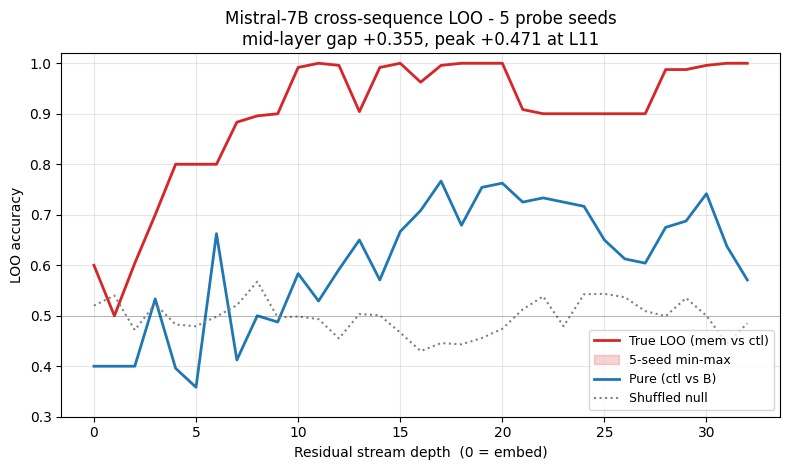

In [15]:
depths = np.arange(NUM_LAYERS)
fig, ax = plt.subplots(1, 1, figsize=(8, 4.8))
ax.plot(depths, true_mean, color='C3', lw=2, label='True LOO (mem vs ctl)')
ax.fill_between(depths, true_min, true_max, color='C3', alpha=0.2, label='5-seed min-max')
ax.plot(depths, pure_mean, color='C0', lw=2, label='Pure (ctl vs B)')
ax.plot(depths, shuf_mean, color='gray', lw=1.5, ls=':', label='Shuffled null')
ax.axhline(0.5, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('Residual stream depth  (0 = embed)'); ax.set_ylabel('LOO accuracy')
ax.set_title(f'Mistral-7B cross-sequence LOO - 5 probe seeds\n'
             f'mid-layer gap {mid_gap:+.3f}, peak {peak_gap:+.3f} at L{peak_depth}')
ax.set_ylim(0.3, 1.02); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_mistral7b_multiseed.png', dpi=300)
plt.savefig(FIGURE_DIR / 'fig_mistral7b_multiseed.pdf')
plt.show()

In [16]:
# Save
out = {
    'config': {'model': MODEL_NAME, 'seeds': SEEDS, 'num_layers': int(NUM_LAYERS),
               'd_model': int(D_MODEL), 'mem_threshold': MEM_THRESH,
               'valid_keys': VALID_KEYS, 'clusters': CLUSTERS},
    'screening': screening,
    'headline': {
        'mid_layer_gap_mean':     mid_gap,
        'mid_layer_gap_seed_std': mid_gap_std,
        'all_transformer_gap':    all_gap,
        'all_transformer_gap_seed_std': all_gap_std,
        'peak_gap':               peak_gap,
        'peak_gap_seed_std':      peak_gap_std,
        'peak_depth':             peak_depth,
        'peak_envelope':          list(peak_envelope),
        'per_seed_mid_gap':       mid_gap_per_seed.tolist(),
        'per_seed_peak_gap':      peak_gap_per_seed.tolist(),
        'shuffled_null_mean':     float(results_shuf.mean()),
    },
    'per_depth': {
        'true_mean': true_mean.tolist(),
        'true_min':  true_min.tolist(),
        'true_max':  true_max.tolist(),
        'pure_mean': pure_mean.tolist(),
        'shuf_mean': shuf_mean.tolist(),
        'gap_mean':  gap_mean.tolist(),
    },
    'raw_results_shape': list(results_true.shape),
}
with open(ARTIFACT_DIR / 'loo_multiseed_mistral7b.json', 'w') as f:
    json.dump(out, f, indent=2)
np.savez(ARTIFACT_DIR / 'loo_raw_mistral7b.npz',
         results_true=results_true, results_pure=results_pure, results_shuf=results_shuf)
print(f'saved to {ARTIFACT_DIR}')

saved to /content/drive/MyDrive/MIDU/artifacts
